In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

print("TF version:", tf.__version__)

TF version: 2.20.0


In [ ]:
df = pd.read_csv('data_cleaned.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,sex,capital.gain,capital.loss,...,relationshipNot-in-family,relationshipOther-relative,relationshipOwn-child,relationshipUnmarried,relationshipWife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.890411,0.218792,132870,0.164329,-0.439738,0.096735,0.485220,0,0,4356,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.506849,0.218792,140359,0.062837,-2.400559,0.107262,0.124619,0,0,3900,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.328767,0.218792,264663,0.200060,-0.047574,0.070288,0.448489,0,0,3900,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.232877,0.218792,216864,0.164329,-0.439738,0.107262,0.041096,0,0,3770,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.287671,0.218792,150601,0.071951,-1.616231,0.070288,0.133835,1,0,3770,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df.shape

(30162, 24)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
TARGET = 'income'
CAT_THRESHOLD = 20
feature_cols = [c for c in df.columns if c != TARGET]

categorical_cols = [
    c for c in feature_cols
    if df[c].dtype == 'object' or df[c].nunique() <= CAT_THRESHOLD
]
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numerical columns  :", numerical_cols)

Categorical columns: ['workclass', 'education', 'education.num', 'marital.status', 'occupation', 'sex', 'relationshipHusband', 'relationshipNot-in-family', 'relationshipOther-relative', 'relationshipOwn-child', 'relationshipUnmarried', 'relationshipWife', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White']
Numerical columns  : ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
df_enc = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    encoders[col] = le

cardinalities = {col: df_enc[col].nunique() for col in categorical_cols}
cardinalities

{'workclass': 7,
 'education': 16,
 'education.num': 16,
 'marital.status': 7,
 'occupation': 14,
 'sex': 2,
 'relationshipHusband': 2,
 'relationshipNot-in-family': 2,
 'relationshipOther-relative': 2,
 'relationshipOwn-child': 2,
 'relationshipUnmarried': 2,
 'relationshipWife': 2,
 'race_Amer-Indian-Eskimo': 2,
 'race_Asian-Pac-Islander': 2,
 'race_Black': 2,
 'race_Other': 2,
 'race_White': 2}

In [ ]:
from sklearn.model_selection import train_test_split

# Drop rows with NaN in the target column before splitting
df_cleaned = df_enc.dropna(subset=[TARGET])

X = df_cleaned[feature_cols]
y = df_cleaned[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

X_train.shape, X_val.shape, X_test.shape

((21716, 23), (2413, 23), (6033, 23))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

if numerical_cols:
    X_train_num = scaler.fit_transform(X_train[numerical_cols])
    X_val_num   = scaler.transform(X_val[numerical_cols])
    X_test_num  = scaler.transform(X_test[numerical_cols])
else:
    X_train_num = np.zeros((len(X_train), 0))
    X_val_num   = np.zeros((len(X_val), 0))
    X_test_num  = np.zeros((len(X_test), 0))

In [ ]:
def make_inputs(X_df, X_num):
    inputs = {}
    for col in categorical_cols:
        inputs[col] = X_df[col].values.astype('int32')
    if numerical_cols:
        inputs['numerical_features'] = X_num.astype('float32')
    return inputs

train_inputs = make_inputs(X_train, X_train_num)
val_inputs   = make_inputs(X_val, X_val_num)
test_inputs  = make_inputs(X_test, X_test_num)

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def embedding_dim(cardinality):
    return int(min(50, (cardinality + 1) // 2)) or 1

inputs_list = []
embedding_outputs = []

for col in categorical_cols:
    card = cardinalities[col]
    emb_dim = embedding_dim(card)

    inp = Input(shape=(1,), name=col)
    emb = Embedding(input_dim=card, output_dim=emb_dim, name=f"{col}_embedding")(inp)
    emb = Flatten()(emb)

    inputs_list.append(inp)
    embedding_outputs.append(emb)

if numerical_cols:
    num_input = Input(shape=(len(numerical_cols),), name='numerical_features')
    inputs_list.append(num_input)
    embedding_outputs.append(num_input)

x = Concatenate()(embedding_outputs) if len(embedding_outputs) > 1 else embedding_outputs[0]

x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

output = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs=inputs_list, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ workclass           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ education           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ education.num       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ marital.status      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ occupation          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sex (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relationshipHusband │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relationshipNot-in… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relationshipOther-… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relationshipOwn-ch… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relationshipUnmarr… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relationshipWife    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_Amer-Indian-E… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_Asian-Pac-Isl… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_Black          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_Other          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_White          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 56,243 (219.70 KB)

 Trainable params: 55,347 (216.20 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
679/679 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7883 - auc: 0.8268 - loss: 0.4748 - val_accuracy: 0.8533 - val_auc: 0.9138 - val_loss: 0.3537 - learning_rate: 0.0010
Epoch 2/100
679/679 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8355 - auc: 0.8833 - loss: 0.3924 - val_accuracy: 0.8525 - val_auc: 0.9134 - val_loss: 0.3487 - learning_rate: 0.0010
Epoch 3/100
679/679 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8371 - auc: 0.8915 - loss: 0.3786 - val_accuracy: 0.8583 - val_auc: 0.9168 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 4/100
679/679 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8425 - auc: 0.8960 - loss: 0.3696 - val_accuracy: 0.8554 - val_auc: 0.9201 - val_loss: 0.3367 - learning_rate: 0.0010
Epoch 5/100
679/679 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8416 - auc: 0.8942 - loss: 0.3693 - val_accuracy: 0.8599 - val_auc: 0.9197 - val_loss: 0.3340 - learning_rate: 0.0010
Epoch 6/100
679/679 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8421 - 

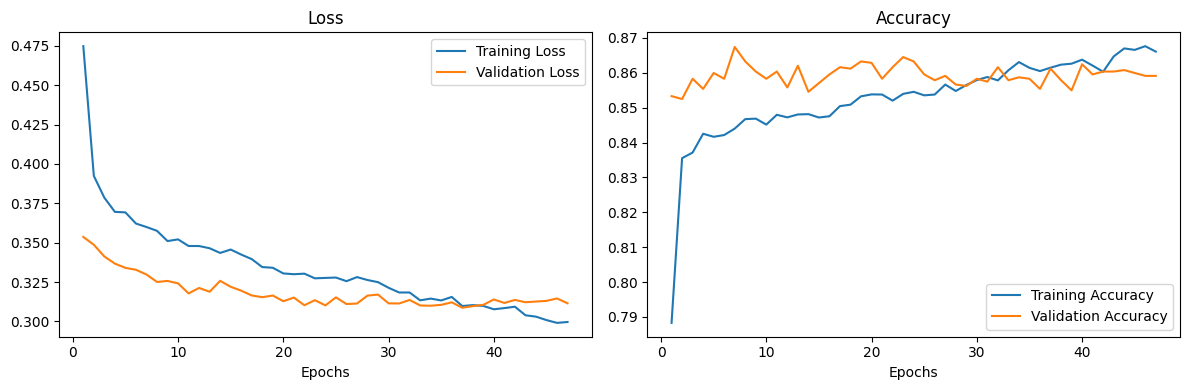

In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
results = model.evaluate(test_inputs, y_test, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

loss: 0.3120
compile_metrics: 0.8652


In [ ]:
y_pred_prob = model.predict(test_inputs).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_pred[:5]

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([0, 0, 1, 0, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4531
           1       0.76      0.67      0.71      1502

    accuracy                           0.87      6033
   macro avg       0.83      0.80      0.81      6033
weighted avg       0.86      0.87      0.86      6033

[[4215  316]
 [ 497 1005]]
ROC-AUC: 0.9205630629770178


In [ ]:
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_pred_prob >= thr).astype(int)
    from sklearn.metrics import f1_score, accuracy_score
    print(f"threshold={thr:.1f}  acc={accuracy_score(y_test, preds):.4f}  f1={f1_score(y_test, preds):.4f}")

threshold=0.3  acc=0.8352  f1=0.7165
threshold=0.4  acc=0.8533  f1=0.7173
threshold=0.5  acc=0.8652  f1=0.7120
threshold=0.6  acc=0.8598  f1=0.6635
threshold=0.7  acc=0.8437  f1=0.5747
